<a href="https://colab.research.google.com/github/Edgar-Avila/mcd101-trabajo-final/blob/main/Prediccion_del_abandono_y_exito_escolar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Librerías necesarias

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###Lectura de datos

In [11]:
url = "https://drive.google.com/uc?id=1JmzingmKDxcQizwszGAD9SxcTFENXKR2"
data = pd.read_csv(url)

In [12]:
print(data.shape)
data.head()

(4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


##Tipo de datos


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

### Limpieza de datos

####Ver si hay valores nulos o filas duplicadas

In [14]:
#Comprobar si hay valores vacios/ nulos
print(data.isnull().sum())

#Filas duplicadas
print("Duplicados:", data.duplicated().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

####Eliminar filas no necesarias

In [15]:
data = data[data["Target"] != "Enrolled"]
data['Target'] = data['Target'].map({'Dropout': 1, 'Graduate': 0})
print(data["Target"].value_counts())


Target
0    2209
1    1421
Name: count, dtype: int64


####Eliminar columnas no necesarias

In [16]:
#Se elimina nacionalidad e international porque no hay variabilidad, la mayoria solo pertenece a 1 (portugues)
data = data.drop(columns=["Nacionality", "International"])
#Ver si el genero afecta al exito o abandono escolar, se concluye que si
data.groupby("Gender")["Target"].value_counts(normalize=True)

Gender  Target
0       0         0.697606
        1         0.302394
1       1         0.561249
        0         0.438751
Name: proportion, dtype: float64

In [17]:
print(data[["Unemployment rate", "Inflation rate", "GDP"]].nunique())
data.groupby("Target")[["Unemployment rate", "Inflation rate", "GDP"]].mean()
# se deduce que no influyen de forma significante en el target lo cual ocasionaria ruido, asi que se elimina

Unemployment rate    10
Inflation rate        9
GDP                  10
dtype: int64


,Unemployment rate,Inflation rate,GDP
Target,,,
0,11.639339,1.197918,0.081833
1,11.616397,1.283955,-0.150859


In [18]:
data = data.drop(columns=[
    "Unemployment rate",
    "Inflation rate",
    "GDP"
])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 30 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance                      3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Mother's qualification                          3630 non-null   int64  
 7   Father's qualification                          3630 non-null   int64  
 8   Mother's occupation                             3630 non-null   int64  
 9   Father's occupation                           

([<matplotlib.patches.Wedge at 0x7a6b6b233ce0>,
 [Text(-0.3678605418272969, 1.0366670737351156, 'Graduated'),
  Text(0.36786087961628566, -1.0366669538708817, 'Dropout')],
 [Text(-0.200651204633071, 0.5654547674918812, '61%'),
  Text(0.20065138888161033, -0.5654547021113899, '39%')])

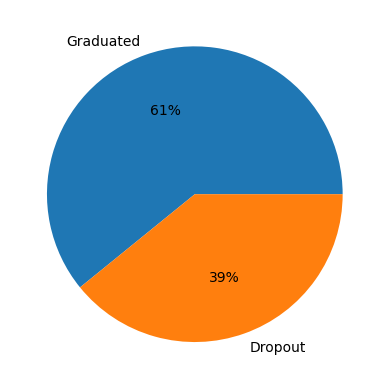

In [19]:
# Visualizar datos objetivo

counts = data["Target"].copy().map({1: "Dropout", 0: "Graduated"}).value_counts()

plt.pie(counts.values, labels=counts.index, autopct='%1.0f%%')

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
)
import numpy as np

In [21]:
# Seleccionar variables (features) y objetivo (target)
# (la mayoría de columnas ya están codificadas numéricamente en este dataset)
X = data.drop(columns=["Target"]).copy()
cat_cols = ["Marital status", "Course", "Gender","Previous qualification", "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", "Application mode"]
X = pd.get_dummies(X, drop_first=True, columns=cat_cols)
y = data["Target"].copy()


# Separar entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Entrenar un clasificador Random Forest simple
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)


# Predicciones y métricas básicas
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9256198347107438
ROC AUC: 0.9726953349053599

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       442
           1       0.94      0.87      0.90       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



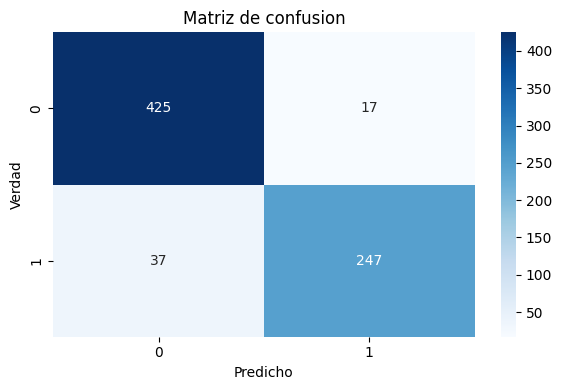

In [22]:
# Visualización de la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion")
plt.xlabel("Predicho")
plt.ylabel("Verdad")
plt.tight_layout()
plt.show()

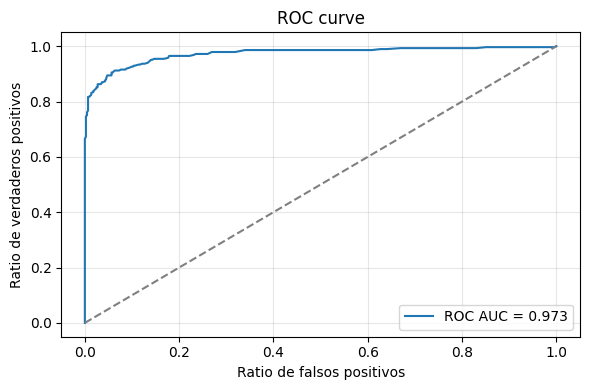

In [23]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Ratio de falsos positivos")
plt.ylabel("Ratio de verdaderos positivos")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10249/3131511871.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=fi, palette="viridis")


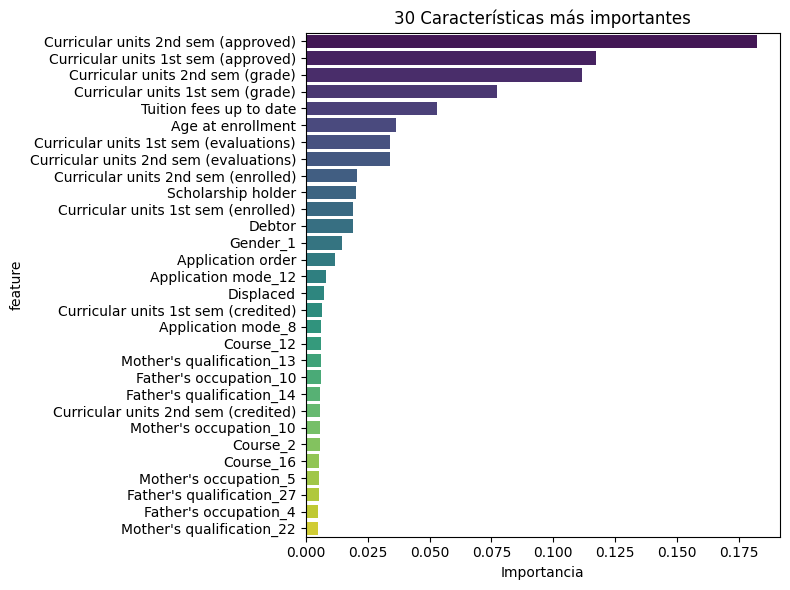

In [24]:
# Importancia de las características (top 15)
importances = clf.feature_importances_
feat_names = X.columns
fi = pd.DataFrame({"feature": feat_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(30)

plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=fi, palette="viridis")
plt.title("30 Características más importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()